In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc
from scipy.stats import spearmanr, shapiro
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

#Motor Vehicle Quota, Quota Premium And Prevailing Quota Premium, Monthly - Feb 2002 to Dec 2024
dataset_id = "d_22094bf608253d36c0c63b52d852dd6e"

#Annual Revalidation of Certificate of Entitlement (COE) of Existing Vehicles - 2006 to 2017
annual_coe_reval = "d_71ce745d4e4ea9cd2fea0fdf46412fc8"

#Monthly Revalidation of COE - Data from Jan 2015 to Jan 2018
monthly_coe_reval = "d_11af4cacfdd459f8712fb903b1639d98"

#Motor Vehicle Population Under Vehicle Quota System, (As At End Of Period), Monthly - May 1990 to Nov 2024
veh_pop = "d_ede1a559013d10f234d209ac5e9fd9b4"

#Motor Vehicles De-Registered Under Vehicle Quota System, Monthly - May 1990 to Nov 2024
veh_dereg = "d_d520d6034b5e0c4f883b4e480de28f97"

#New Registration Of Motor Vehicles Under Vehicle Quota System , Monthly - May 1990 to Nov 2024
veh_reg = "d_529752a3d78beb78bd4f38e3be37f1b6"


In [2]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + dataset_id

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)

results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')

results_df['bidding'] = results_df['DataSeries'].apply(
    lambda x: 1 if "1st Bidding" in x else (
        2 if '2nd Bidding' in x else 0
        )
    )

results_df['coe_category'] = results_df['DataSeries'].apply(
    lambda x: 'A' if 'Cars Up To 1600cc' in x else (
        'B' if 'Cars Above 1600cc' in x else (
            'C' if 'Goods Vehicles & Buses' in x else (
                'D' if 'Motorcycles' in x else (
                    'E' if 'Open Category' in x else None
                )
            )
        )
        
    )
)

results_df['quota'] = np.nan
results_df['bids_received'] = np.nan
results_df['successful_bids'] = np.nan
results_df['quota_premium'] = np.nan

results_df.loc[
    (results_df['DataSeries'].str.contains('Quota', case=False)) & 
    (~results_df['DataSeries'].str.contains('Premium', case=False)),
    'quota'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Bids Received', case=False)),
    'bids_received'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Successful Bids', case=False)),
    'successful_bids'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Quota Premium', case=False)) &
    (~results_df['DataSeries'].str.contains('Prevailing', case=False)),
    'quota_premium'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Prevailing Quota Premium', case=False)),
    'prevailing_quota_premium'
] = results_df['value']

results_df.dropna(subset=['coe_category'], inplace=True)

agg_df = results_df.pivot_table(
    index = ['month', 'bidding', 'coe_category'],
    values=['quota', 'bids_received', 'successful_bids', 'quota_premium', 'prevailing_quota_premium'],
    aggfunc='first'
).reset_index()

agg_df.set_index(['month', 'bidding', 'coe_category'], inplace=True)
agg_df.sort_values(['month', 'bidding', 'coe_category'], inplace=True)

coe_df = agg_df.copy()

In [3]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_dereg

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'dereg_a': 'Category A',
    'dereg_b': 'Category B',
    'dereg_c': 'Category C',
    'dereg_offpeak': 'Weekend Cars/Off Peak Cars',
    'dereg_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['dereg_a', 'dereg_b', 'dereg_c', 'dereg_offpeak', 'dereg_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_dereg_df = agg_df.copy()

In [4]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_reg

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'new_a': 'Category A',
    'new_b': 'Category B',
    'new_c': 'Category C',
    'new_offpeak': 'Weekend Cars/Off Peak Cars',
    'new_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['new_a', 'new_b', 'new_c', 'new_offpeak', 'new_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_new_df = agg_df.copy()

In [5]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_pop

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'pop_a': 'Category A',
    'pop_b': 'Category B',
    'pop_c': 'Category C',
    'pop_offpeak': 'Weekend Cars/Off Peak Cars',
    'pop_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['pop_a', 'pop_b', 'pop_c', 'pop_offpeak', 'pop_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_pop_df = agg_df.copy()

In [6]:
cat_a = coe_df.xs(key='A', level='coe_category')
cat_a_df = cat_a.groupby('month').agg({
    'quota': 'sum',
    'bids_received': 'sum',
    'successful_bids': 'sum',
    'quota_premium': 'mean',
    'prevailing_quota_premium': 'mean'
}).add_suffix('_a')

veh_dereg_cat_a = veh_dereg_df[['dereg_a']]
veh_new_cat_a = veh_new_df[['new_a']]
veh_pop_cat_a = veh_pop_df[['pop_a']]

cat_a_df = cat_a_df.merge(veh_dereg_cat_a, left_index=True, right_index=True, how='left')
cat_a_df = cat_a_df.merge(veh_new_cat_a, left_index=True, right_index=True, how='left')
cat_a_df = cat_a_df.merge(veh_pop_cat_a, left_index=True, right_index=True, how='left')

columns = ['quota_a', 'bids_received_a', 'successful_bids_a']
cat_a_df[columns] = cat_a_df[columns].replace(0, np.nan)

cat_a_df.loc['2024-12-01', ['dereg_a', 'new_a', 'pop_a']] = [1973, 2928, 321611]
cat_a_df[cat_a_df.isna().any(axis=1)]

,quota_a,bids_received_a,successful_bids_a,quota_premium_a,prevailing_quota_premium_a,dereg_a,new_a,pop_a
month,,,,,,,,
2020-04-01,NaN,NaN,NaN,NaN,32875.0,1707.0,263.0,319683.0
2020-05-01,NaN,NaN,NaN,NaN,32875.0,1184.0,13.0,318512.0
2020-06-01,NaN,NaN,NaN,NaN,32875.0,1756.0,449.0,317205.0
2025-08-01,2532.0,3677.0,2514.0,103266.5,100644.0,2891.0,NaN,322505.0
2025-09-01,2547.0,4365.0,2537.0,113446.0,105939.0,2263.0,NaN,322084.0
2025-10-01,2538.0,4540.0,2501.0,125052.5,113922.0,2672.0,NaN,321522.0


In [7]:
cat_a = cat_a_df.copy()
cat_a.interpolate(method='time', inplace=True)

def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic = {result[0]:.3f}, p-value = {result[1]:.5f}")

def shapiro_test(series):
    stat, p = shapiro(series)
    print(f"Shapiro-Wilk Statistic = {stat:.3f}, p-value = {p:.5f}")

def ljung_box_test(series, lags=12):
    result = acorr_ljungbox(series, lags=[lags], return_df=True)
    print(f"Ljung-Box p-value = {result['lb_pvalue'].iloc[0]:.5f}")

def bp_test(series):
    residuals = series.values
    x = sm.add_constant(range(len(residuals)))
    _, pval, _, _ = sm.stats.diagnostic.het_breuschpagan(residuals, x)
    print(f"Breusch-Pagan p-value = {pval:.5f}")

for col in cat_a.columns:
    print(f"\nTests for {col}")
    adf_test(cat_a[col])
    shapiro_test(cat_a[col])
    ljung_box_test(cat_a[col])
    bp_test(cat_a[col])


Tests for quota_a
ADF Statistic = -2.669, p-value = 0.07949
Shapiro-Wilk Statistic = 0.945, p-value = 0.00000
Ljung-Box p-value = 0.00000
Breusch-Pagan p-value = 0.00000

Tests for bids_received_a
ADF Statistic = -1.735, p-value = 0.41339
Shapiro-Wilk Statistic = 0.948, p-value = 0.00000
Ljung-Box p-value = 0.00000
Breusch-Pagan p-value = 0.00000

Tests for successful_bids_a
ADF Statistic = -2.597, p-value = 0.09369
Shapiro-Wilk Statistic = 0.945, p-value = 0.00000
Ljung-Box p-value = 0.00000
Breusch-Pagan p-value = 0.00000

Tests for quota_premium_a
ADF Statistic = 0.749, p-value = 0.99076
Shapiro-Wilk Statistic = 0.945, p-value = 0.00000
Ljung-Box p-value = 0.00000
Breusch-Pagan p-value = 0.00000

Tests for prevailing_quota_premium_a
ADF Statistic = -0.694, p-value = 0.84841
Shapiro-Wilk Statistic = 0.942, p-value = 0.00000
Ljung-Box p-value = 0.00000
Breusch-Pagan p-value = 0.00000

Tests for dereg_a
ADF Statistic = -2.014, p-value = 0.28060
Shapiro-Wilk Statistic = 0.944, p-value 

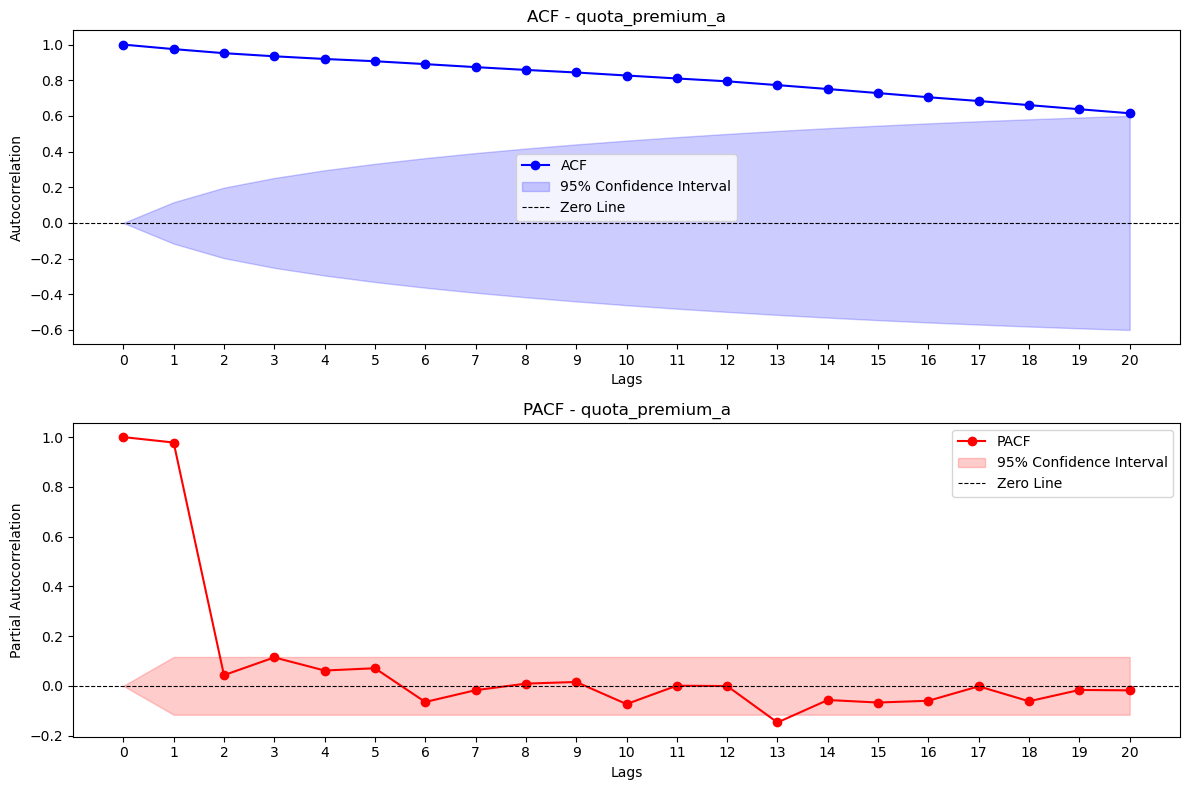

In [8]:
data = cat_a['quota_premium_a'].dropna()

lags = 20
acf_values, acf_confint = acf(data, nlags=lags, alpha=0.05)
pacf_values, pacf_confint = pacf(data, nlags=lags, alpha=0.05)

lags_range = np.arange(len(acf_values))

plt.figure(figsize=(12, 8))

# Plot ACF
plt.subplot(2, 1, 1)
plt.plot(lags_range, acf_values, marker='o', label='ACF', color='blue')
plt.fill_between(
    lags_range,
    acf_confint[:, 0] - acf_values,
    acf_confint[:, 1] - acf_values,
    color='blue',
    alpha=0.2,
    label='95% Confidence Interval'
)
plt.axhline(0, linestyle='--', color='black', linewidth=0.8, label='Zero Line')
plt.title("ACF - quota_premium_a")
plt.xlabel("Lags")
plt.xticks(lags_range)
plt.ylabel("Autocorrelation")
plt.legend()

# Plot PACF
plt.subplot(2, 1, 2)
plt.plot(lags_range, pacf_values, marker='o', label='PACF', color='red')
plt.fill_between(
    lags_range,
    pacf_confint[:, 0] - pacf_values,
    pacf_confint[:, 1] - pacf_values,
    color='red',
    alpha=0.2,
    label='95% Confidence Interval'
)
plt.axhline(0, linestyle='--', color='black', linewidth=0.8, label='Zero Line')
plt.title("PACF - quota_premium_a")
plt.xlabel("Lags")
plt.xticks(lags_range)
plt.ylabel("Partial Autocorrelation")
plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()


ACF insights: slow decay suggests persistent autocorrelation and non-stationarity. Also seen by BP test

PACF insights: significant value at lag 1 above 95% CI. Suggest strong lag-1 relationship, making AR(1) suitable candidate

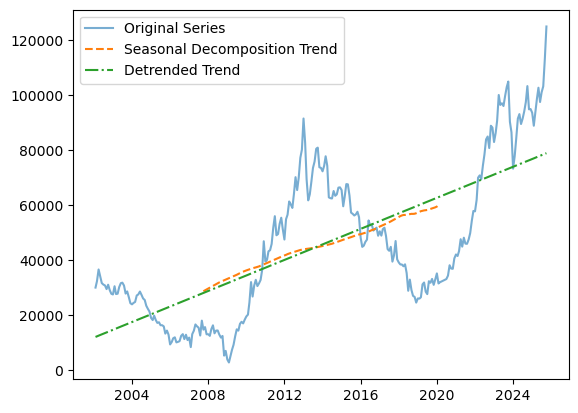

In [9]:
decomposed = seasonal_decompose(cat_a['quota_premium_a'], model='additive', period=137)
seasonal_trend = decomposed.trend

# Detrended trend
detrended_series = sm.tsa.detrend(cat_a['quota_premium_a'], order=1)
detrended_trend = cat_a['quota_premium_a'] - detrended_series

# Plot comparison
plt.plot(cat_a['quota_premium_a'], label='Original Series', alpha=0.6)
plt.plot(seasonal_trend, label='Seasonal Decomposition Trend', linestyle='--')
plt.plot(detrended_trend, label='Detrended Trend', linestyle='-.')
plt.legend()
plt.show()



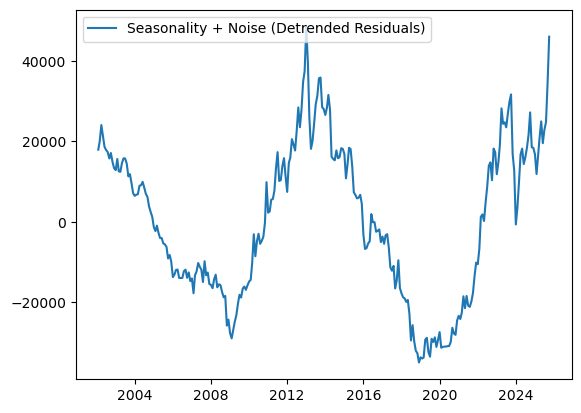

In [10]:
detrended_residuals = cat_a['quota_premium_a'] - detrended_trend

# Plot the residuals
plt.plot(detrended_residuals, label="Seasonality + Noise (Detrended Residuals)")
plt.legend()
plt.show()


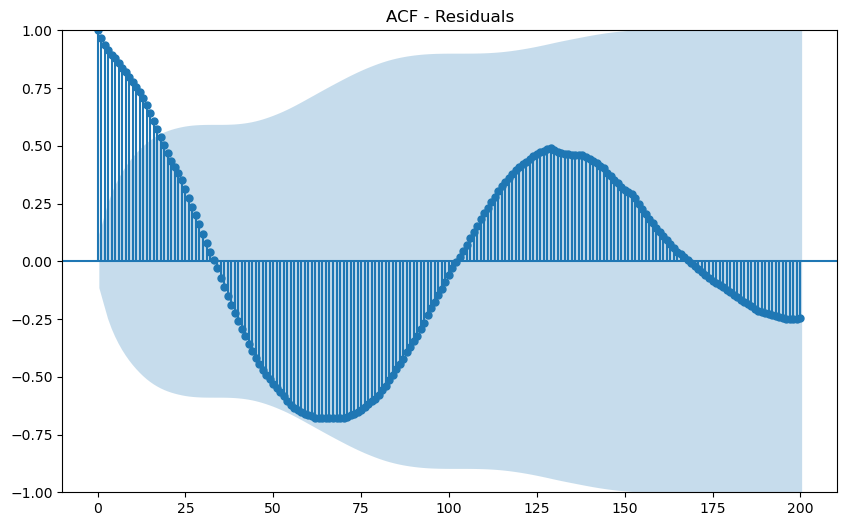

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Residuals (replace with your actual residual data)
residuals = detrended_residuals  # Replace with the residual series you want to analyze

# Plot ACF
plt.figure(figsize=(10, 6))
plot_acf(residuals, lags=200, alpha=0.05, zero=True, title="ACF - Residuals", ax=plt.gca())
plt.show()


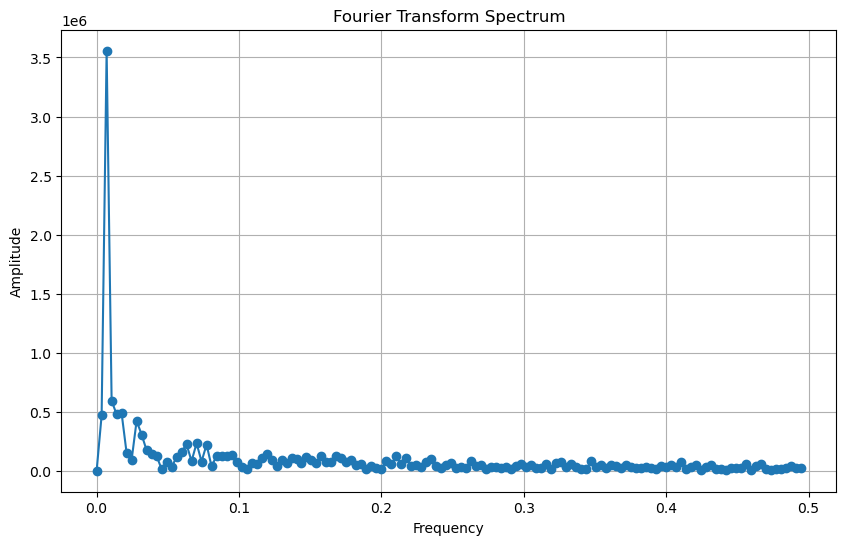

Dominant Frequency: 0.007017543859649123
Estimated Seasonal Period: 142.5 time steps


In [12]:
from scipy.fftpack import fft, fftfreq

# Assume `residuals` is your time series data
n = len(residuals)  # Number of observations
timestep = 1        # Time step (e.g., monthly data has a step of 1 month)

# Compute Fourier Transform
fft_result = fft(residuals.values)
fft_magnitude = np.abs(fft_result)  # Get magnitude of FFT
frequencies = fftfreq(n, d=timestep)  # Frequencies in the FFT result

positive_freqs = frequencies[:n // 2]
positive_magnitude = fft_magnitude[:n // 2]

plt.figure(figsize=(10, 6))
plt.plot(positive_freqs, positive_magnitude, marker='o')
plt.title('Fourier Transform Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

dominant_freq = positive_freqs[np.argmax(positive_magnitude)]
dominant_period = 1 / dominant_freq
print(f"Dominant Frequency: {dominant_freq}")
print(f"Estimated Seasonal Period: {dominant_period} time steps")


Frequencies and Amplitudes of Peaks between 0.0 and 0.1:
Frequency: 0.0070, Amplitude: 3557258.2418
Period: 142.50 time steps

Frequency: 0.0175, Amplitude: 487076.5968
Period: 57.00 time steps

Frequency: 0.0281, Amplitude: 421925.8900
Period: 35.62 time steps

Frequency: 0.0491, Amplitude: 73740.7824
Period: 20.36 time steps

Frequency: 0.0632, Amplitude: 222450.1283
Period: 15.83 time steps

Frequency: 0.0702, Amplitude: 232816.5021
Period: 14.25 time steps

Frequency: 0.0772, Amplitude: 221490.1396
Period: 12.95 time steps

Frequency: 0.0842, Amplitude: 126100.2769
Period: 11.88 time steps

Frequency: 0.0947, Amplitude: 129708.3949
Period: 10.56 time steps



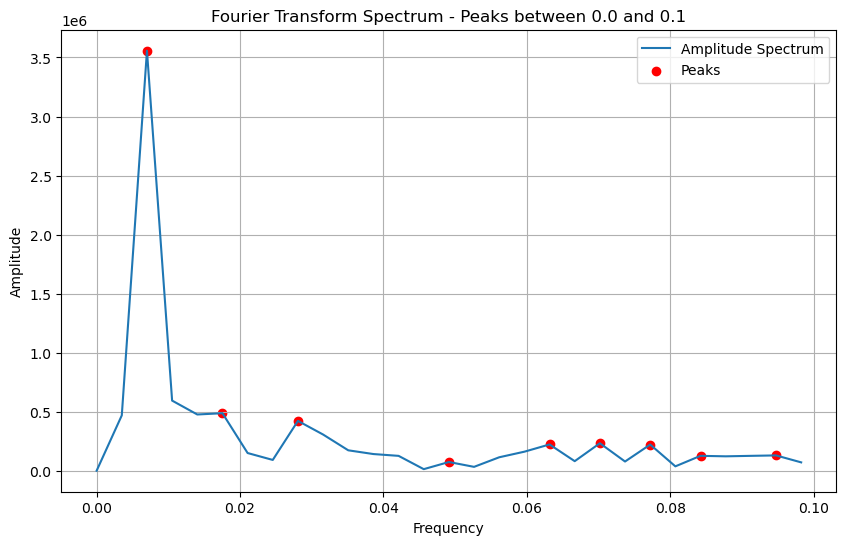

In [13]:
from scipy.signal import find_peaks

# Define the range of interest for frequencies (0.0 to 0.1)
freq_range_mask = (frequencies >= 0.0) & (frequencies <= 0.1)

# Extract the frequencies and amplitudes in the desired range
frequencies_in_range = frequencies[freq_range_mask]
amplitude_in_range = fft_magnitude[freq_range_mask]

# Find the peaks in the range
peaks, _ = find_peaks(amplitude_in_range)

# Get the frequencies and amplitudes of the peaks
peak_frequencies = frequencies_in_range[peaks]
peak_amplitudes = amplitude_in_range[peaks]

# Print the results
print("Frequencies and Amplitudes of Peaks between 0.0 and 0.1:")
for freq, amp in zip(peak_frequencies, peak_amplitudes):
    print(f"Frequency: {freq:.4f}, Amplitude: {amp:.4f}")
    period = 1 / freq
    print(f"Period: {period:.2f} time steps\n")

# Plot the peaks on the graph for visualization
plt.figure(figsize=(10, 6))
plt.plot(frequencies_in_range, amplitude_in_range, label="Amplitude Spectrum")
plt.scatter(peak_frequencies, peak_amplitudes, color='red', label="Peaks")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.title("Fourier Transform Spectrum - Peaks between 0.0 and 0.1")
plt.legend()
plt.grid()
plt.show()


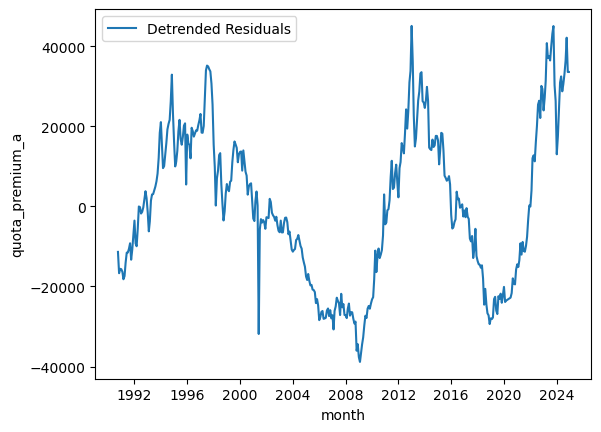

In [14]:
new_data = pd.read_csv('coe.csv', names=['month', 'quota_premium_a'])
new_data.set_index('month', inplace=True)
new_data.index = pd.to_datetime(new_data.index, format='%d/%m/%Y', errors='coerce')

new_data['quota_premium_a'] = new_data['quota_premium_a'].replace('#VALUE!', 0)
new_data['quota_premium_a'] = new_data['quota_premium_a'].str.replace(',', '')
new_data['quota_premium_a'] = pd.to_numeric(new_data['quota_premium_a'], errors='coerce')
new_data.interpolate(method='time', inplace=True)
new_data.sort_index(inplace=True)

detrend = sm.tsa.detrend(new_data['quota_premium_a'], order=1)

sns.lineplot(data=detrend, label='Detrended Residuals')
plt.show()


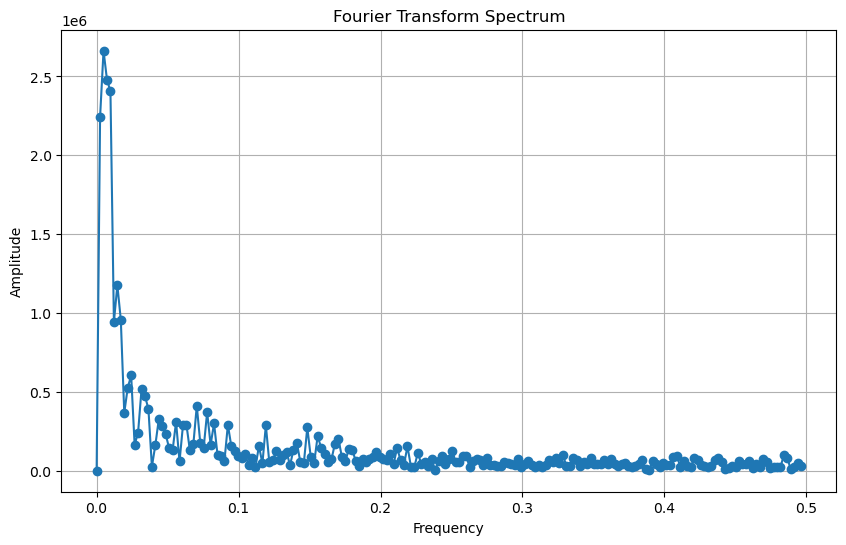

Dominant Frequency: 0.004866180048661801
Estimated Seasonal Period: 205.5 time steps


In [15]:
residuals = detrend
n = len(residuals)
timestep = 1 

# Compute Fourier Transform
fft_result = fft(residuals.values)
fft_magnitude = np.abs(fft_result)  # Get magnitude of FFT
frequencies = fftfreq(n, d=timestep)  # Frequencies in the FFT result

positive_freqs = frequencies[:n // 2]
positive_magnitude = fft_magnitude[:n // 2]

plt.figure(figsize=(10, 6))
plt.plot(positive_freqs, positive_magnitude, marker='o')
plt.title('Fourier Transform Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

dominant_freq = positive_freqs[np.argmax(positive_magnitude)]
dominant_period = 1 / dominant_freq
print(f"Dominant Frequency: {dominant_freq}")
print(f"Estimated Seasonal Period: {dominant_period} time steps")

Frequencies and Amplitudes of Peaks between 0.0 and 0.1:
Frequency: 0.0049, Amplitude: 2663217.5547
Period: 205.50 time steps

Frequency: 0.0146, Amplitude: 1176878.6992
Period: 68.50 time steps

Frequency: 0.0243, Amplitude: 604311.9398
Period: 41.10 time steps

Frequency: 0.0316, Amplitude: 516448.3521
Period: 31.62 time steps

Frequency: 0.0438, Amplitude: 326458.3064
Period: 22.83 time steps

Frequency: 0.0560, Amplitude: 309403.9468
Period: 17.87 time steps

Frequency: 0.0633, Amplitude: 292547.8814
Period: 15.81 time steps

Frequency: 0.0706, Amplitude: 411207.7556
Period: 14.17 time steps

Frequency: 0.0779, Amplitude: 371332.8653
Period: 12.84 time steps

Frequency: 0.0827, Amplitude: 300165.2368
Period: 12.09 time steps

Frequency: 0.0925, Amplitude: 290820.3773
Period: 10.82 time steps



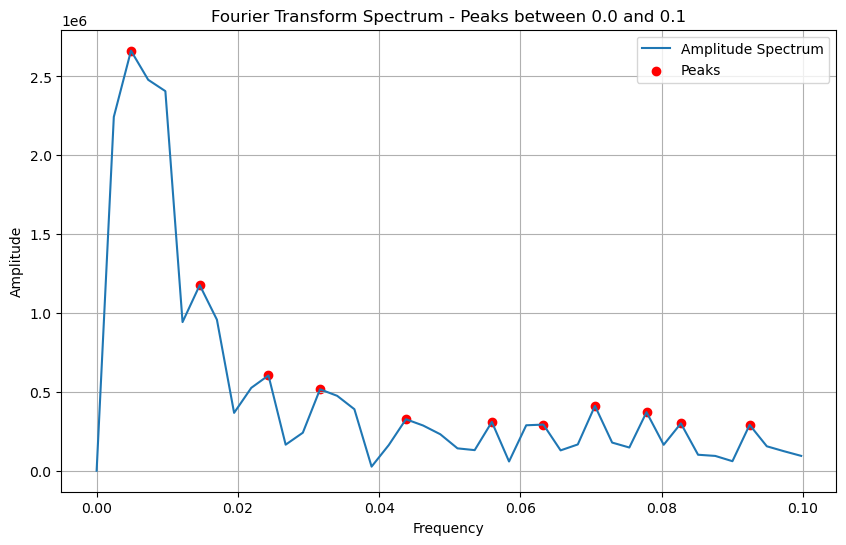

In [16]:
freq_range_mask = (frequencies >= 0.0) & (frequencies <= 0.1)

# Extract the frequencies and amplitudes in the desired range
frequencies_in_range = frequencies[freq_range_mask]
amplitude_in_range = fft_magnitude[freq_range_mask]

# Find the peaks in the range
peaks, _ = find_peaks(amplitude_in_range)

# Get the frequencies and amplitudes of the peaks
peak_frequencies = frequencies_in_range[peaks]
peak_amplitudes = amplitude_in_range[peaks]

# Print the results
print("Frequencies and Amplitudes of Peaks between 0.0 and 0.1:")
for freq, amp in zip(peak_frequencies, peak_amplitudes):
    print(f"Frequency: {freq:.4f}, Amplitude: {amp:.4f}")
    period = 1 / freq
    print(f"Period: {period:.2f} time steps\n")

# Plot the peaks on the graph for visualization
plt.figure(figsize=(10, 6))
plt.plot(frequencies_in_range, amplitude_in_range, label="Amplitude Spectrum")
plt.scatter(peak_frequencies, peak_amplitudes, color='red', label="Peaks")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.title("Fourier Transform Spectrum - Peaks between 0.0 and 0.1")
plt.legend()
plt.grid()
plt.show()

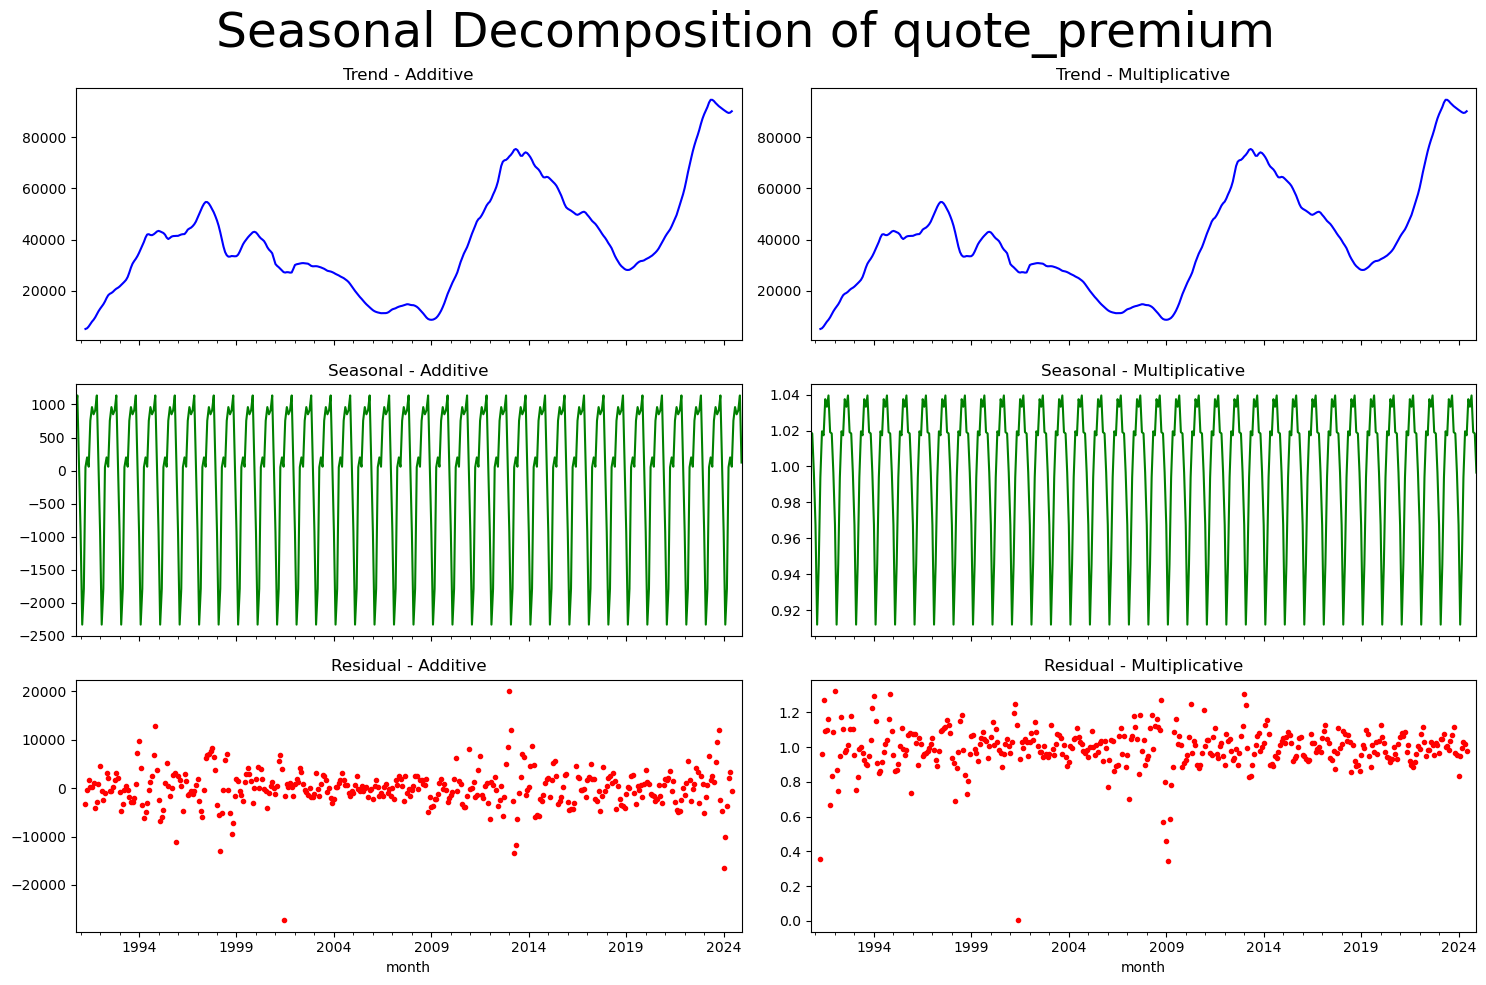

In [17]:
decomp_results = {'additive': {}, 'multiplicative': {}}

for model in ['additive', 'multiplicative']:
    decomp = seasonal_decompose(new_data['quota_premium_a'], model=model, period=12)
    decomp_results[model]['trend'] = decomp.trend
    decomp_results[model]['seasonal'] = decomp.seasonal
    decomp_results[model]['residual'] = decomp.resid

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
fig.suptitle(f"Seasonal Decomposition of quote_premium", fontsize=35)

decomp_results['additive']['trend'].plot(ax=axes[0, 0], title='Trend - Additive', color='blue')
decomp_results['additive']['seasonal'].plot(ax=axes[1, 0], title='Seasonal - Additive', color='green')
decomp_results['additive']['residual'].plot(ax=axes[2, 0], title='Residual - Additive', color='red', style='.')

decomp_results['multiplicative']['trend'].plot(ax=axes[0, 1], title='Trend - Multiplicative', color='blue')
decomp_results['multiplicative']['seasonal'].plot(ax=axes[1, 1], title='Seasonal - Multiplicative', color='green')
decomp_results['multiplicative']['residual'].plot(ax=axes[2, 1], title='Residual - Multiplicative', color='red', style='.')

plt.tight_layout()
plt.show()


In [18]:
add_resid = decomp_results['additive']['residual']
mul_resid = decomp_results['multiplicative']['residual']

adf_test(add_resid.dropna())
adf_test(mul_resid.dropna())
shapiro_test(add_resid.dropna())
shapiro_test(mul_resid.dropna())
ljung_box_test(add_resid.dropna())
ljung_box_test(mul_resid.dropna())
bp_test(add_resid.dropna())
bp_test(mul_resid.dropna())

ADF Statistic = -8.960, p-value = 0.00000
ADF Statistic = -9.611, p-value = 0.00000
Shapiro-Wilk Statistic = 0.911, p-value = 0.00000
Shapiro-Wilk Statistic = 0.849, p-value = 0.00000
Ljung-Box p-value = 0.00000
Ljung-Box p-value = 0.00000
Breusch-Pagan p-value = 0.99878
Breusch-Pagan p-value = 0.60244


In [19]:
from statsmodels.tsa.arima.model import ARIMA

ar_add = ARIMA(add_resid.dropna(), order=(1, 0, 0), freq='MS').fit()
print(ar_add.summary())

ar_mul = ARIMA(mul_resid.dropna(), order=(1, 0, 0), freq='MS').fit()
print(ar_mul.summary())

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  399
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3821.299
Date:                Tue, 27 Jan 2026   AIC                           7648.598
Time:                        15:31:49   BIC                           7660.565
Sample:                    04-01-1991   HQIC                          7653.337
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.8692    352.635     -0.039      0.969    -705.021     677.282
ar.L1          0.4669      0.027     17.219      0.000       0.414       0.520
sigma2       1.22e+07   3.35e+05     36.369      0.0

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARCH Test Statistic: 7.242117070613951, p-value: 0.702406964233741


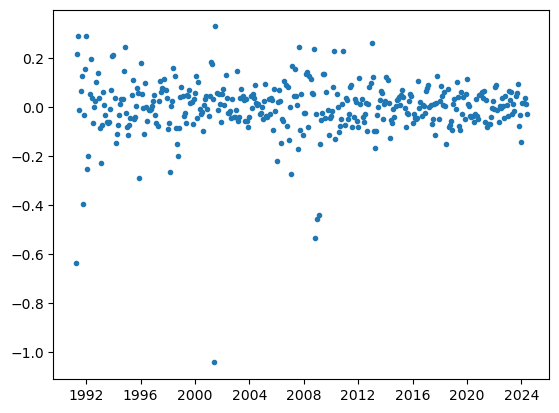

In [20]:
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(ar_mul.resid.dropna())
print(f"ARCH Test Statistic: {arch_test[0]}, p-value: {arch_test[1]}")

plt.plot(ar_mul.resid, label='Residuals', marker='.', linestyle='None')
plt.show()

#p-value > 0.05, no conditional heteroskedasticity

In [21]:
from scipy.stats import boxcox

print("Min value in residuals:", ar_mul.resid.min())
print("Number of NaN values:", ar_mul.resid.isna().sum())

clean_resid = ar_mul.resid[ar_mul.resid > -1]

#log1p if data contains 0, working with very small numbers
log_residuals = np.log1p(clean_resid)

shapiro_test(log_residuals.dropna())
bp_test(log_residuals.dropna())

boxcox_resid, lambda_ = boxcox(clean_resid + 1)
shapiro_test(boxcox_resid)

def bp_test(series):
    # Use the input directly if it's a NumPy array
    residuals = series if isinstance(series, np.ndarray) else series.values
    x = sm.add_constant(range(len(residuals)))
    _, pval, _, _ = sm.stats.diagnostic.het_breuschpagan(residuals, x)
    print(f"Breusch-Pagan p-value: {pval}")
    return pval

bp_test(boxcox_resid)

clean_mul_resid = mul_resid[mul_resid > -1]
log_mul_resid = np.log1p(clean_mul_resid)

ar_log_mul = ARIMA(log_mul_resid.dropna(), order=(1, 0, 0), freq='MS').fit()
print(ar_log_mul.summary())



Min value in residuals: -1.042783340775093
Number of NaN values: 0
Shapiro-Wilk Statistic = 0.779, p-value = 0.00000
Breusch-Pagan p-value = 0.01115
Shapiro-Wilk Statistic = 0.950, p-value = 0.00000
Breusch-Pagan p-value: 1.2849156110773626e-05
                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  399
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 523.421
Date:                Tue, 27 Jan 2026   AIC                          -1040.841
Time:                        15:31:49   BIC                          -1028.874
Sample:                    04-01-1991   HQIC                         -1036.102
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [22]:
print(f"Mul: MSE: {ar_mul.mse}, AIC: {ar_mul.aic}, BIC: {ar_mul.bic}")
print(f"Log Mul: MSE: {ar_log_mul.mse}, AIC: {ar_log_mul.aic}, BIC: {ar_log_mul.bic}")


Mul: MSE: 0.013450073850349832, AIC: -585.4874028461295, BIC: -573.5205185954599
Log Mul: MSE: 0.0042930270115258354, AIC: -1040.8410829744414, BIC: -1028.8741987237718


In [23]:
train_size = int(len(mul_resid) * 0.8)
train_mul_resid = mul_resid[:train_size]
test_mul_resid = mul_resid[train_size:]

print(train_mul_resid.isna().sum())
print(test_mul_resid.isna().sum())

train_mul_resid[train_mul_resid.isna()]
test_mul_resid[test_mul_resid.isna()]

mul_resid[mul_resid.isna()]
mul_resid.head(20)

#fill missing values with mean
mul_resid.fillna(mul_resid.mean(), inplace=True)
mul_resid.head()

mul_resid.isna().sum()

6
6


0

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Train-test split (80% train, 20% test)
train_size = int(len(mul_resid) * 0.95)
train_mul_resid = mul_resid[:train_size]
test_mul_resid = mul_resid[train_size:]

# Fit AR(1) model on training data
model_train_mul = ARIMA(train_mul_resid, order=(1, 0, 0), freq='MS').fit()

# Forecast on the test set
forecast_mul = model_train_mul.get_forecast(steps=len(test_mul_resid))
forecast_values_mul = forecast_mul.predicted_mean

# Evaluate the model
mse_test_mul = mean_squared_error(test_mul_resid, forecast_values_mul)
mae_test_mul = mean_absolute_error(test_mul_resid, forecast_values_mul)

print(f"MSE (Multiplicative Model Test): {mse_test_mul}")
print(f"MAE (Multiplicative Model Test): {mae_test_mul}")

# Repeat for log-multiplicative residuals
train_log_mul_resid = log_mul_resid[:train_size]
test_log_mul_resid = log_mul_resid[train_size:]

model_train_log_mul = ARIMA(train_log_mul_resid, order=(1, 0, 0), freq='MS').fit()
forecast_log_mul = model_train_log_mul.get_forecast(steps=len(test_log_mul_resid))
forecast_values_log_mul = forecast_log_mul.predicted_mean

mse_test_log_mul = mean_squared_error(test_log_mul_resid, forecast_values_log_mul)
mae_test_log_mul = mean_absolute_error(test_log_mul_resid, forecast_values_log_mul)

print(f"MSE (Log-Multiplicative Model Test): {mse_test_log_mul}")
print(f"MAE (Log-Multiplicative Model Test): {mae_test_log_mul}")


MSE (Multiplicative Model Test): 0.0028013801563704435
MAE (Multiplicative Model Test): 0.03238224601666837
MSE (Log-Multiplicative Model Test): 0.001192074619951314
MAE (Log-Multiplicative Model Test): 0.025635471871238


c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


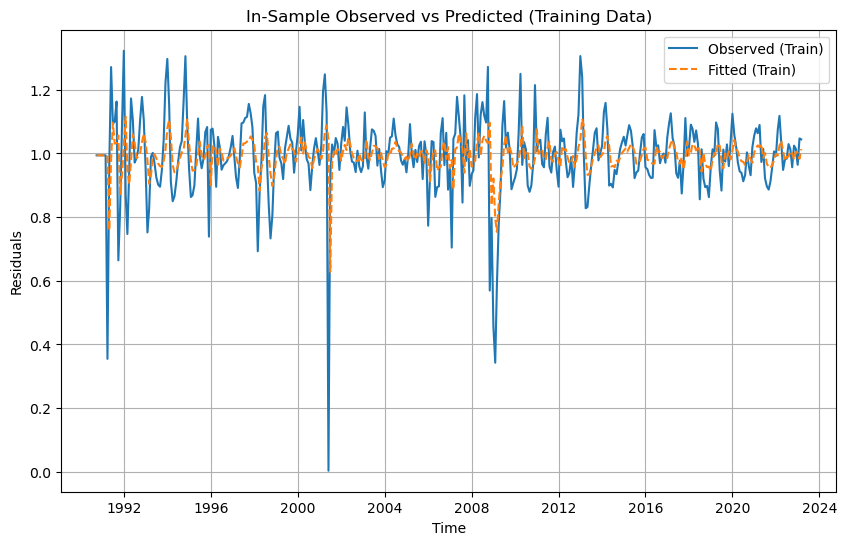

In [25]:

plt.figure(figsize=(10, 6))
plt.plot(train_mul_resid.index, train_mul_resid, label="Observed (Train)", linestyle="-")
plt.plot(train_mul_resid.index, model_train_mul.fittedvalues, label="Fitted (Train)", linestyle="--")
plt.title("In-Sample Observed vs Predicted (Training Data)")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.legend()
plt.grid()
plt.show()


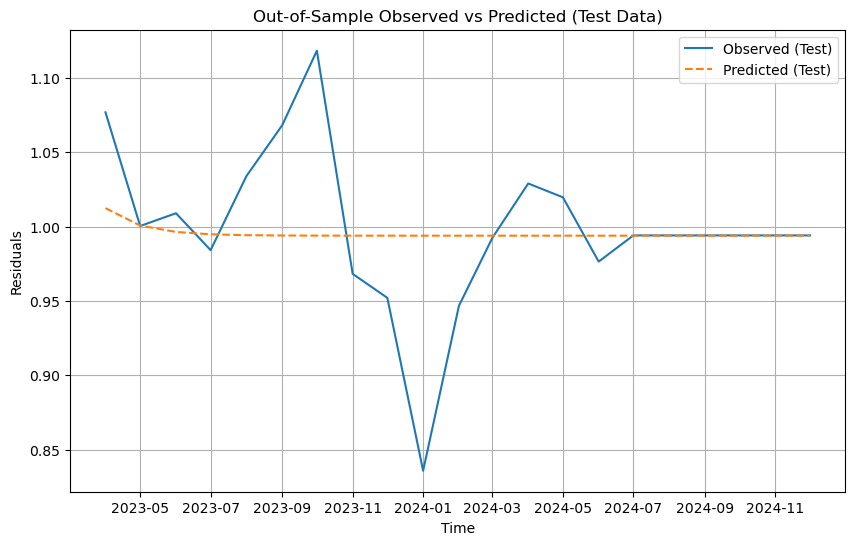

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(test_mul_resid.index, test_mul_resid, label="Observed (Test)", linestyle="-")
plt.plot(test_mul_resid.index, forecast_values_mul, label="Predicted (Test)", linestyle="--")
plt.title("Out-of-Sample Observed vs Predicted (Test Data)")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.legend()
plt.grid()
plt.show()